In [ ]:
#Imports
import torch
import random
import os
from numpy import genfromtxt
import numpy as np
import matplotlib.pyplot as plt
import csv
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pandas as pd
import diffrax
import equinox as eqx
import jax
import jax.nn as jnn
import jax.random as jr
import optax
from tqdm import tqdm

path = os.getcwd() + "/ambr"
files = os.listdir(path)
files_xls = [f for f in files if f[-3:] == 'csv']
df = pd.DataFrame()
files_xls

df = [None] * len(files_xls)

for f in range(len(files_xls)):
    data = pd.read_csv(path + "/" + files_xls[f])

    data.columns = data.columns.str.strip()
    data.columns = data.columns.str.replace('\ufeff', '', regex=False)

    if "Time" not in data.columns:
        print(files_xls[f], data.columns.tolist())
        raise ValueError(f"No Time column in {files_xls[f]}")

    # Extract run tag from filename
    run_name = files_xls[f].replace(".csv", "")

    df[f] = data
    df[f] = df[f].loc[:, ~df[f].columns.duplicated()]
    df[f] = df[f].sort_values("Time").reset_index(drop=True)
    df[f] = df[f].drop(columns=[c for c in df[f].columns
             if ('Optical density' not in c)
             and ('DO' not in c) 
             and ('pH' not in c) 
             and ('Time' not in c)])

In [149]:
run2_5_10  = ["Time" if x == "Time" else x + " run2" for x in df[0].columns]
run1_19_24 = ["Time" if x == "Time" else x + " run1" for x in df[1].columns]
run1_13_18 = ["Time" if x == "Time" else x + " run1" for x in df[2].columns]
run2_11_16 = ["Time" if x == "Time" else x + " run2" for x in df[3].columns]
run2_17_22 = ["Time" if x == "Time" else x + " run2" for x in df[4].columns]

# List of lists, one per dataframe
new_names = [run2_5_10, run1_19_24, run1_13_18, run2_11_16, run2_17_22]

# Now assign
for d in range(len(df)):
    df[d].columns = new_names[d]

df_merged = df[0].copy()

for d in range(1, len(df)):
    df_merged = pd.merge(df_merged, df[d], on="Time", how="outer")

df_merged = df_merged.sort_values("Time").reset_index(drop=True)

path = os.getcwd() + "/Lorena_dataset/Glucose_files_310326/OfflineMetabolites_AMBR1.csv"
glucose1 = pd.read_csv(path, delimiter=';')
path = os.getcwd() + "/Lorena_dataset/Glucose_files_310326/OfflineMetabolites_AMBR2.xlsx"
glucose2 = pd.read_excel(path)


glc1 = glucose1[["Reactor","Time","Glucose"]]
glc2 = glucose2[["Reactor","Time","Glucose Vanquish"]]

In [150]:
glucose_df = pd.DataFrame()
bior = None

for i in range(1, len(df_merged.columns), 3):
    name_split = df_merged.columns[i].rsplit(" ")
            #s = glucose_df[bb].dropna()
    run_tag = name_split[-1]
    bio_name = name_split[0] + " " + name_split[1]
    column = bio_name + " - " + run_tag

    if "run1" in run_tag:
        bior = glc1[glc1["Reactor"] == bio_name][["Time", "Glucose"]].copy()
        bior = bior.rename(columns={"Glucose": f"{bio_name} {run_tag}"})
    elif "run2" in run_tag:
        bior = glc2[glc2["Reactor"] == bio_name][["Time", "Glucose Vanquish"]].copy()
        bior = bior.rename(columns={"Glucose Vanquish": f"{bio_name} {run_tag}"})

    # Rename Glucose column
    bior = bior.rename(columns={"Glucose": f"{bio_name} {run_tag}"})

    # Merge into glucose_df
    if glucose_df.empty:
        glucose_df = bior
    else:
        glucose_df = pd.merge(glucose_df, bior, on="Time", how="outer")

glucose_df = glucose_df.sort_values("Time").reset_index(drop=True)

In [151]:
cols = list(df_merged.columns)
for i, col in enumerate(cols):
    if "Optical density" not in col:
        continue
    new_col_name = col.replace("Optical density", "Biomass")
    ph_col = col.replace("Optical density", "pH")
    ph_idx = df_merged.columns.get_loc(ph_col)
    df_merged.insert(ph_idx + 1, new_col_name, df_merged[col] * 0.4267)

df_merged = df_merged.drop(columns=[c for c in df_merged.columns
            if ('Optical' in c)])

In [152]:
#Lets start the loop to delete the NaNs !
ts_list = []
ys_list = []

list_bior = []

for i in range(0, len(df_merged.columns)-1, 3):
# --- OD, pH, Biomass ---
    name_split = df_merged.columns[1:][i].rsplit(" ", 3)
        #s = glucose_df[bb].dropna()
    bio_name = name_split[0] + " " + name_split[-1]

    list_bior.append(bio_name)

    s = glucose_df[bio_name].dropna()
    ts = glucose_df.loc[s.index, "Time"]

    ts_list.append(ts.to_numpy(dtype=np.float32))
    ys_list.append(s.to_numpy(dtype=np.float32))
    
    s1 = df_merged[df_merged.columns[1:][i:i+3][0]].dropna()
    s2 = df_merged[df_merged.columns[1:][i:i+3][1]].dropna()
    s3 = df_merged[df_merged.columns[1:][i:i+3][2]].dropna()

    indices_1 = s1.index
    indices_2 = s2.index
    indices_3 = s3.index

    ts1 = df_merged.loc[s1.index, "Time"]
    ts2 = df_merged.loc[s2.index, "Time"]
    ts3 = df_merged.loc[s3.index, "Time"]

    ts_list.extend([ts1.to_numpy(dtype=np.float32), ts2.to_numpy(dtype=np.float32), ts3.to_numpy(dtype=np.float32)])
    ys_list.extend([s1.to_numpy(dtype=np.float32),  s2.to_numpy(dtype=np.float32),  s3.to_numpy(dtype=np.float32)])

In [153]:
"""
        axs[var_idx].plot(time, traj, "o",label="Ground truth", linewidth=2, markersize=2)
        axs[var_idx].set_title(glucose_df.columns[i] + " - " + name)
        axs[var_idx].set_xlabel("Time (h)")
        axs[var_idx].set_ylabel(units[var_idx])
        axs[var_idx].legend()
        ymin, ymax = axs[var_idx].get_ylim()
#slope = np.max(np.gradient(traj, time))
        axs[var_idx].text(
            time[-1] * 0.7,
            ymin + 0.7 * (ymax - ymin),
            f"AUC = {np.trapezoid(traj,x=time):.4f}\n"
            f"max_slope = {np.max(np.gradient(traj, time)):.4f}\n"
            f"max = {ymax:.4f}\n"
            f"min = {ymin:.4f}\n"
            f"first = {traj[0]:.4f}\n"
            f"last = {time[-1]:.4f}\n"
        )
        axs[var_idx].grid(True)"""

'\n        axs[var_idx].plot(time, traj, "o",label="Ground truth", linewidth=2, markersize=2)\n        axs[var_idx].set_title(glucose_df.columns[i] + " - " + name)\n        axs[var_idx].set_xlabel("Time (h)")\n        axs[var_idx].set_ylabel(units[var_idx])\n        axs[var_idx].legend()\n        ymin, ymax = axs[var_idx].get_ylim()\n#slope = np.max(np.gradient(traj, time))\n        axs[var_idx].text(\n            time[-1] * 0.7,\n            ymin + 0.7 * (ymax - ymin),\n            f"AUC = {np.trapezoid(traj,x=time):.4f}\n"\n            f"max_slope = {np.max(np.gradient(traj, time)):.4f}\n"\n            f"max = {ymax:.4f}\n"\n            f"min = {ymin:.4f}\n"\n            f"first = {traj[0]:.4f}\n"\n            f"last = {time[-1]:.4f}\n"\n        )\n        axs[var_idx].grid(True)'

In [154]:
from scipy.differentiate import derivative
dct = {}

for i in range(1, len(glucose_df.columns)-1):
    var_names = ["Glucose", "DO", "pH", "Biomass"]
    units = ["", "", "", ""]
    list_values = []
    # --- Plot predictions vs ground truth ---
    #fig, axs = plt.subplots(1, 4, figsize=(24, 5))
    for var_idx, name in enumerate(var_names):
        list_values_var = []

        time = ts_list[i*4+var_idx]
        traj = ys_list[i*4+var_idx]
        auc = np.trapezoid(traj, x=time)
        auc_normalized = auc / (time[-1] - time[0])

        list_values_var = [auc_normalized, np.max(np.gradient(traj, time)), max(traj), min(traj), traj[0], traj[-1]]
        list_values += list_values_var

    l = glucose_df.columns[i].split(" ")

    element = {"B" + l[1] + "R" + l[2][-1] : list_values}
    dct.update(element)


In [155]:
l_index = ["AUC_Glucose", "Slope_Glucose", "Max_Glucose", "Min_Glucose", "First_Glucose", "Last_Glucose",
           "AUC_DO", "Slope_DO", "Max_DO", "Min_DO", "First_DO", "Last_DO",
           "AUC_pH", "Slope_pH", "Max_pH", "Min_pH", "First_pH", "Last_pH",
           "AUC_Biomass", "Slope_Biomass", "Max_Biomass", "Min_Biomass", "First_Biomass", "Last_Biomass"]

df = pd.DataFrame(data=dct, index=l_index)

In [156]:
df

,B5R2,B6R2,B7R2,B8R2,B9R2,B10R2,B19R1,B21R1,B22R1,B23R1,...,B12R2,B13R2,B14R2,B15R2,B16R2,B17R2,B18R2,B19R2,B20R2,B21R2
AUC_Glucose,2.484216,2.428545,2.502352,7.282180,7.481539,5.816508,2.972102,3.061195,2.960363,2.710904,...,1.525845,1.450599,2.453568,2.326725,9.301512,9.276217,3.437278,3.520077,4.142637,5.346602
Slope_Glucose,0.020000,0.070000,0.000000,0.020000,0.000000,0.302062,0.000000,0.000000,0.000000,0.000000,...,0.040000,0.045610,0.020000,0.010000,0.178242,0.229075,0.018151,0.000000,0.006667,0.580000
Max_Glucose,10.260000,10.050000,10.270000,20.559999,20.250000,9.962565,10.348804,10.156742,10.167679,10.356501,...,7.170000,6.840000,10.210000,10.340000,10.100000,10.310000,10.220000,10.280000,10.400000,10.440000
Min_Glucose,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,8.160000,7.840000,0.000000,0.000000,0.000000,0.000000
First_Glucose,10.260000,10.050000,10.270000,20.559999,20.250000,9.962565,10.348804,10.156742,10.167679,10.356501,...,7.170000,6.840000,10.210000,10.340000,9.870000,10.120000,10.220000,10.280000,10.400000,10.440000
Last_Glucose,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.060000,0.000000,0.030000,0.000000,8.160000,7.870000,0.010000,0.000000,0.010000,0.000000
AUC_DO,99.999290,78.342201,77.377487,63.027538,63.350235,100.015121,91.848274,84.743996,78.738266,73.182022,...,83.607590,83.062836,76.215782,75.030861,1.357282,1.256141,55.216679,52.245144,43.717541,25.781296
Slope_DO,371.315308,417.421570,350.498840,229.982300,253.872559,161.414703,86.446869,145.393250,212.154099,288.557861,...,700.020386,892.537476,325.403442,390.559998,69.656586,153.688629,252.172958,298.326843,318.585510,330.715851
Max_DO,161.267822,99.741631,99.935722,99.691109,100.101021,114.240395,102.347870,102.261696,102.237518,102.495934,...,131.575073,160.720367,99.789803,100.017776,97.509689,98.371574,99.942101,99.694145,99.993088,99.970535
Min_DO,93.663933,14.968204,15.755876,13.964615,12.923063,72.203117,74.181747,54.203346,33.783932,15.256792,...,10.385330,11.962222,1.169085,1.087785,-0.280194,-0.245339,-0.481969,-0.420991,-0.432156,-0.402156


In [157]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

dt = df.T

X = dt.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
print(np.cumsum(pca.explained_variance_ratio_))

[2.4369495e-01 2.2725835e-01 1.3983038e-01 1.3021389e-01 6.7379579e-02
 5.9450753e-02 5.4993272e-02 2.7409440e-02 2.1394979e-02 1.3140115e-02
 5.2743419e-03 4.2860080e-03 2.4152144e-03 1.2897584e-03 1.0937456e-03
 4.1135127e-04 2.7020564e-04 1.4209538e-04 3.9325681e-05 5.4449119e-06
 4.7598851e-06 1.5470210e-06 4.5812024e-07 3.1327103e-09]
[0.24369495 0.4709533  0.6107837  0.74099755 0.80837715 0.8678279
 0.92282116 0.9502306  0.97162557 0.9847657  0.99004006 0.99432606
 0.9967413  0.9980311  0.9991248  0.99953616 0.99980634 0.99994844
 0.9999878  0.9999932  0.999998   0.9999995  1.         1.        ]


In [158]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_pca[:, :4])

cluster_colors = {
    0: "royalblue",
    1: "darkorange",
    2: "forestgreen",
    3 : "purple"
}

colors = [cluster_colors[c] for c in clusters]

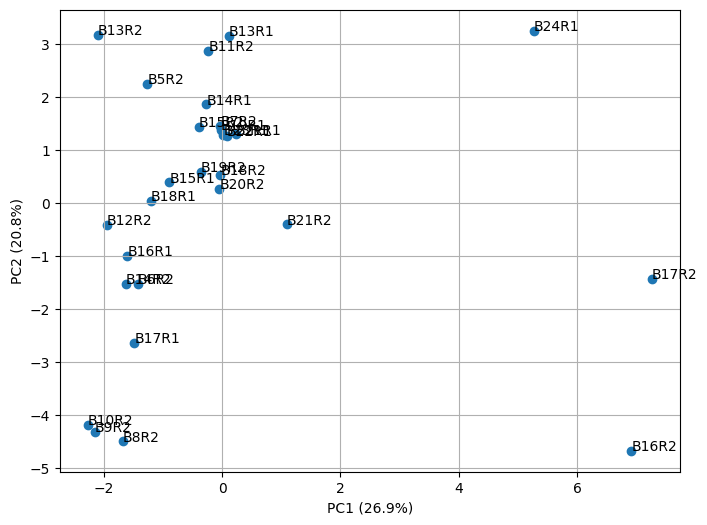

In [159]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1]
)

for i, bio in enumerate(dt.index):
    plt.annotate(
        bio,
        (X_pca[i, 0], X_pca[i, 1])
    )

plt.xlabel("PC1 (26.9%)")
plt.ylabel("PC2 (20.8%)")
plt.grid()
plt.show()

In [160]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=dt.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

print(
    loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

Last_Glucose     0.386493
Min_Glucose      0.386374
Last_DO          0.337457
First_DO         0.317492
AUC_Glucose      0.277841
AUC_Biomass      0.259195
AUC_DO           0.256247
Slope_DO         0.169962
Min_pH           0.167187
Slope_Glucose    0.167107
Slope_pH         0.164244
First_pH         0.163156
Max_Biomass      0.161007
AUC_pH           0.155831
Last_pH          0.152648
Name: PC1, dtype: float32


In [161]:
print(
    loadings["PC2"]
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

Last_pH          0.372050
Max_pH           0.371619
AUC_pH           0.371285
Min_pH           0.365595
First_pH         0.365247
Max_Glucose      0.229858
First_Glucose    0.226269
AUC_Glucose      0.218268
AUC_DO           0.168941
Last_DO          0.161192
First_DO         0.155498
Max_DO           0.141290
First_Biomass    0.115914
Slope_DO         0.101408
Min_DO           0.100439
Name: PC2, dtype: float32


In [162]:
print(
    loadings["PC3"]
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

First_Glucose    0.432936
Max_Glucose      0.429566
AUC_Biomass      0.340105
Slope_DO         0.272709
Slope_Biomass    0.253867
Max_Biomass      0.250904
Max_DO           0.220754
Slope_pH         0.180435
AUC_Glucose      0.178869
Max_pH           0.172759
Last_pH          0.170379
First_pH         0.168947
Min_pH           0.168052
AUC_pH           0.166897
Last_DO          0.112159
Name: PC3, dtype: float32


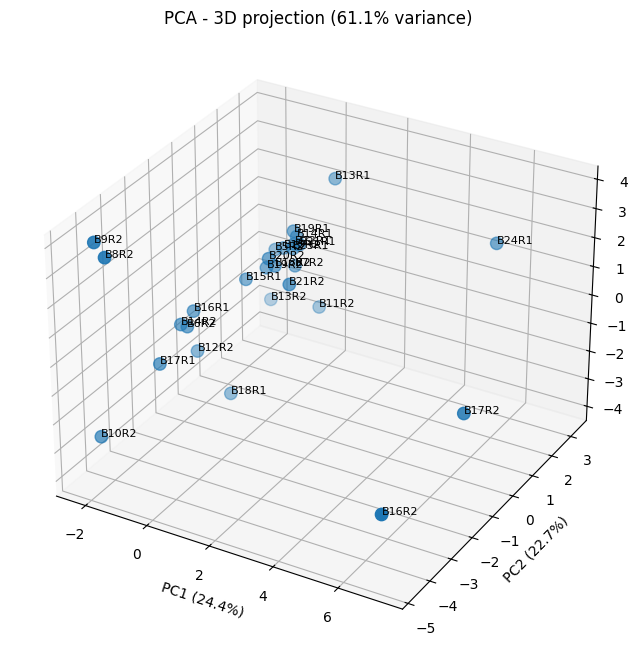

In [163]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X_pca[:, 0],  # PC1
    X_pca[:, 1],  # PC2
    X_pca[:, 2],  # PC3
    s=80
)

# Nom de chaque bioreacteur
for i, bio in enumerate(dt.index):
    ax.text(
        X_pca[i, 0],
        X_pca[i, 1],
        X_pca[i, 2],
        str(bio),
        fontsize=8
    )

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)
ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)
ax.set_zlabel(
    f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)"
)

ax.set_title(
    f"PCA - 3D projection "
    f"({np.sum(pca.explained_variance_ratio_[:3])*100:.1f}% variance)"
)

plt.show()

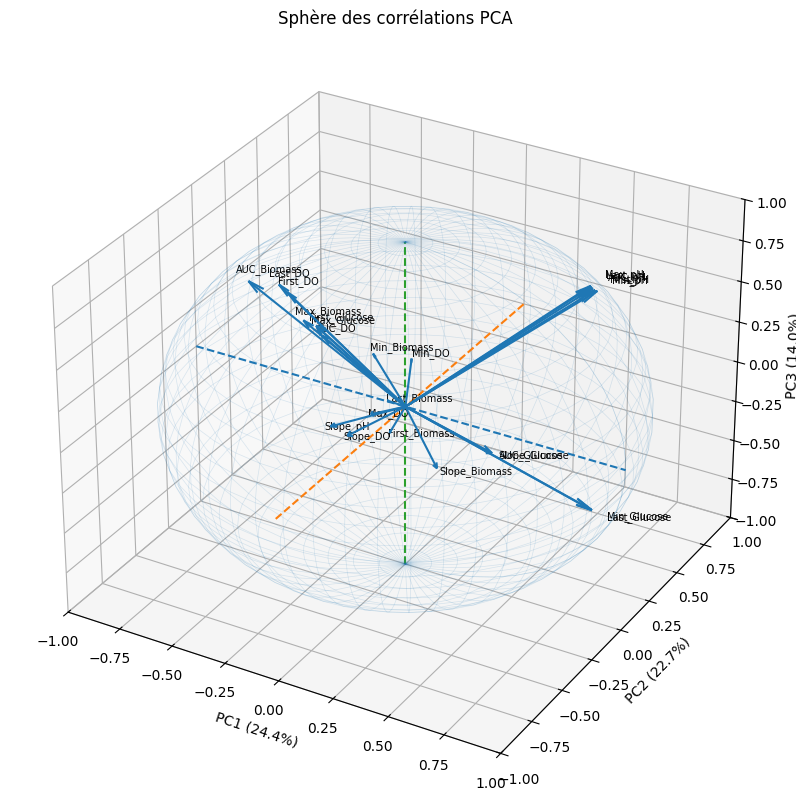

In [164]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

coordonnees_variables = (
    pca.components_.T * np.sqrt(pca.explained_variance_)
)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")

# Sphère unité
u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0, np.pi, 30)

x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones_like(u), np.cos(v))

ax.plot_wireframe(
    x, y, z,
    alpha=0.15,
    linewidth=0.5
)

# Axes
ax.plot([-1, 1], [0, 0], [0, 0], linestyle="--")
ax.plot([0, 0], [-1, 1], [0, 0], linestyle="--")
ax.plot([0, 0], [0, 0], [-1, 1], linestyle="--")

# Variables
for i in range(coordonnees_variables.shape[0]):

    x_var = coordonnees_variables[i, 0]
    y_var = coordonnees_variables[i, 1]
    z_var = coordonnees_variables[i, 2]

    ax.quiver(
        0, 0, 0,
        x_var, y_var, z_var,
        arrow_length_ratio=0.08
    )

    ax.text(
        x_var * 1.08,
        y_var * 1.08,
        z_var * 1.08,
        dt.columns[i],
        fontsize=7
    )

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)
ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)
ax.set_zlabel(
    f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)"
)

ax.set_title("Sphère des corrélations PCA")

plt.show()

In [165]:
pca.components_.shape

(24, 24)

In [166]:
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display

angles = range(0, 360, 18)

files = []

for angle in angles:

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        X_pca[:, 2],
        c=clusters,
        s=80
    )

    for i, bio in enumerate(dt.index):
        ax.text(
            X_pca[i, 0],
            X_pca[i, 1],
            X_pca[i, 2],
            str(bio),
            fontsize=7
        )

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")

    ax.view_init(elev=25, azim=angle)
    ax.set_title(f"PCA 3D - angle = {angle}°")

    filename = f"features_before{angle}.png"
    fig.savefig(filename, bbox_inches="tight", dpi=150)

    # IMPORTANT : ferme la frame pour ne pas l'afficher
    plt.close(fig)

    files.append(filename)


# Création du GIF
images = [Image.open(f) for f in files]

images[0].save(
    "myimage_before.gif",
    save_all=True,
    append_images=images[1:],
    duration=200,
    loop=0
)

for im in images:
    im.close()

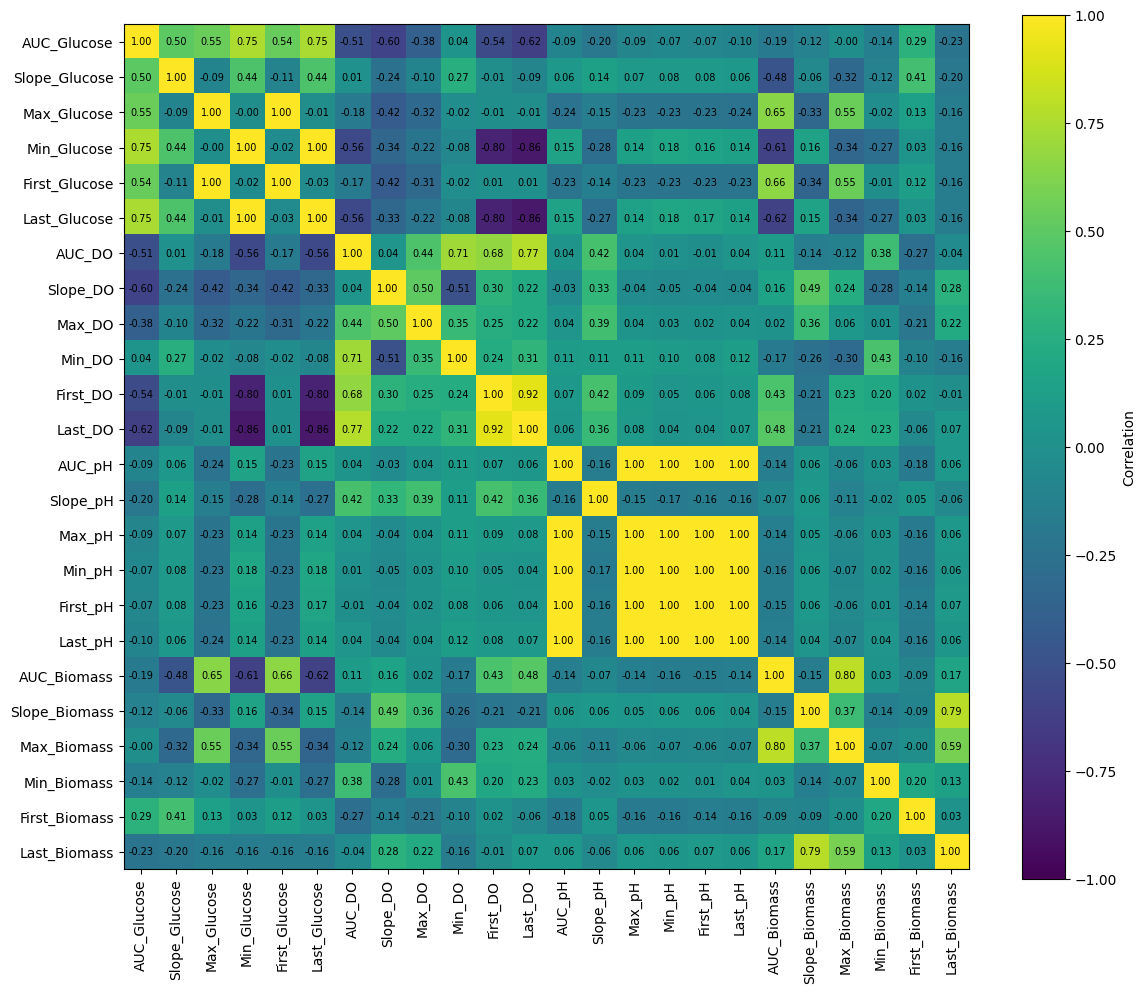

In [167]:
corr = dt.corr()

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(corr, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)

ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

fig.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

In [168]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=dt.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

print(loadings[["PC1", "PC2"]])

                    PC1       PC2
AUC_Glucose    0.277841 -0.218268
Slope_Glucose  0.167107 -0.010169
Max_Glucose   -0.029247 -0.229858
Min_Glucose    0.386374 -0.080930
First_Glucose -0.036032 -0.226269
Last_Glucose   0.386493 -0.078979
AUC_DO        -0.256247  0.168941
Slope_DO      -0.169962  0.101408
Max_DO        -0.146391  0.141290
Min_DO        -0.044018  0.100439
First_DO      -0.317492  0.155498
Last_DO       -0.337457  0.161192
AUC_pH         0.155831  0.371285
Slope_pH      -0.164244  0.034514
Max_pH         0.151695  0.371619
Min_pH         0.167187  0.365595
First_pH       0.163156  0.365247
Last_pH        0.152648  0.372050
AUC_Biomass   -0.259195 -0.065428
Slope_Biomass  0.023710  0.066662
Max_Biomass   -0.161007 -0.055465
Min_Biomass   -0.093622  0.057032
First_Biomass  0.035208 -0.115914
Last_Biomass  -0.075179  0.072644


In [169]:
selected_features = [
    # Glucose
    "AUC_Glucose",
    "Slope_Glucose",
    "First_Glucose",
    "Last_Glucose",

    # DO
    "AUC_DO",
    "Slope_DO",
    "Min_DO",

    # pH
    "AUC_pH",
    "Slope_pH",

    # Biomass
    "AUC_Biomass",
    "Slope_Biomass",
    "Max_Biomass",
    "Last_Biomass"
]

features_reduced = dt[selected_features]

In [170]:
X_scaled = StandardScaler().fit_transform(features_reduced)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
print(np.cumsum(pca.explained_variance_ratio_))
#Donc il faut environ 5 composantes pour représenter ~87 % de l'information, ou 6 pour dépasser 90 %.

[0.2688786  0.20816769 0.18909726 0.1062965  0.09445584 0.06003573
 0.03591429 0.02264166 0.00585066 0.00488662 0.00168763 0.00127073
 0.00081679]
[0.2688786  0.4770463  0.66614354 0.77244    0.86689585 0.92693156
 0.96284586 0.9854875  0.9913382  0.9962248  0.99791247 0.9991832
 1.        ]


In [171]:
X_cluster = X_pca[:, :5]

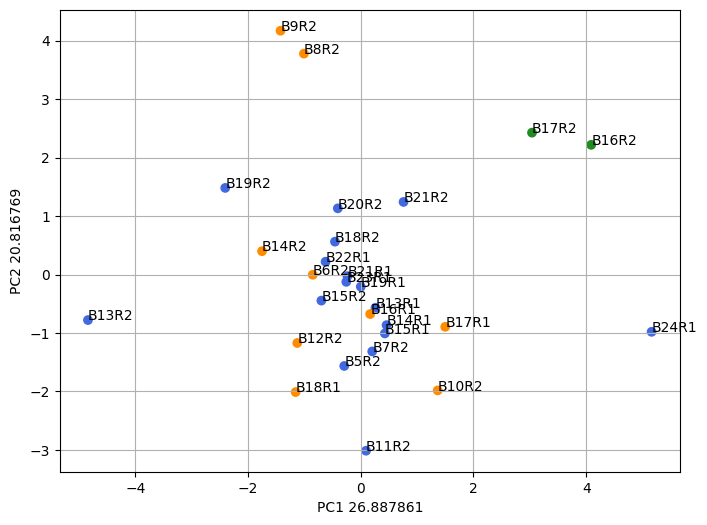

In [172]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=colors
)

for i, bio in enumerate(features_reduced.index):
    plt.annotate(
        bio,
        (X_pca[i, 0], X_pca[i, 1])
    )

plt.xlabel("PC1 " + str(pca.explained_variance_ratio_[0]*100))
plt.ylabel("PC2 " + str(pca.explained_variance_ratio_[1]*100))
plt.grid()
plt.show()

In [173]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

K = range(2, 13)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_cluster)

    score = silhouette_score(X_cluster, labels)
    silhouette_scores.append(score)

    print(f"k={k}: silhouette = {score:.3f}")

k=2: silhouette = 0.422
k=3: silhouette = 0.352
k=4: silhouette = 0.390
k=5: silhouette = 0.307
k=6: silhouette = 0.349
k=7: silhouette = 0.364
k=8: silhouette = 0.368
k=9: silhouette = 0.370
k=10: silhouette = 0.354
k=11: silhouette = 0.329
k=12: silhouette = 0.318


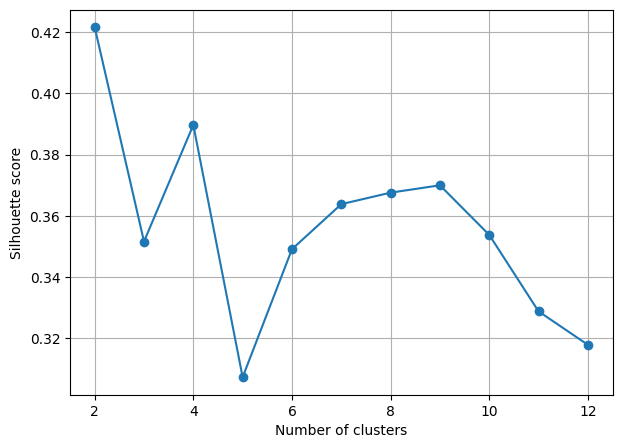

In [174]:
plt.figure(figsize=(7, 5))

plt.plot(K, silhouette_scores, "o-")

plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.grid()

plt.show()

In [175]:
best_k = 4

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_cluster)

cluster_colors = {
    0: "royalblue",
    1: "darkorange",
    2: "forestgreen",
    3 : "purple"
}

colors = [cluster_colors[c] for c in clusters]

In [176]:
pca_df = pd.DataFrame(
    X_pca[:, :5],
    index=features_reduced.index,
    columns=["PC1", "PC2", "PC3", "PC4", "PC5"]
)

pca_df["Cluster"] = colors

print(pca_df)

            PC1       PC2       PC3       PC4       PC5      Cluster
B5R2  -0.292443 -1.563480 -1.452599  0.249012 -0.014730       purple
B6R2  -0.850905 -0.003819 -0.498706 -1.136159  0.152503       purple
B7R2   0.204047 -1.314905 -0.460932 -1.540524  0.177738       purple
B8R2  -1.007430  3.778140 -2.197859 -0.010075  1.197990  forestgreen
B9R2  -1.422804  4.170198 -2.429498  0.007312  1.153358  forestgreen
B10R2  1.365070 -1.981752 -1.286876 -0.246681  3.638351       purple
B19R1  0.001059 -0.207444 -1.085871  0.850162 -1.481060       purple
B21R1 -0.235764 -0.027109 -0.582803  0.564796 -1.377081       purple
B22R1 -0.623668  0.219550 -0.301990  0.242381 -1.201886       purple
B23R1 -0.255966 -0.124687 -0.178579 -0.729419 -0.982875       purple
B24R1  5.159792 -0.979608  0.386996  2.491110  0.614529    royalblue
B13R1  0.261333 -0.567596 -0.987430  1.792983 -1.555009       purple
B14R1  0.458107 -0.865291 -1.145931  0.807012 -1.524577       purple
B15R1  0.428321 -1.007156 -1.28206

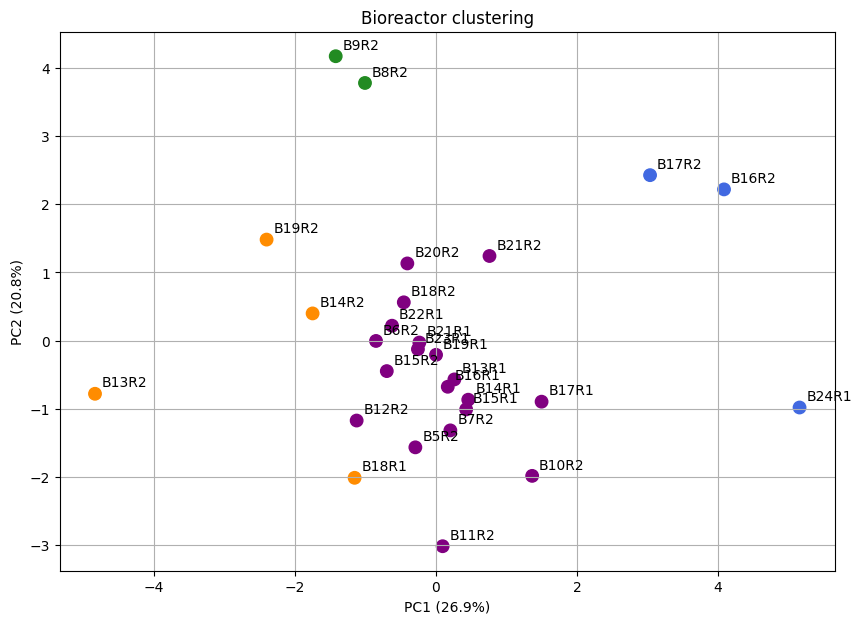

In [177]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    s=80
)

for bio in pca_df.index:
    ax.annotate(
        bio,
        (
            pca_df.loc[bio, "PC1"],
            pca_df.loc[bio, "PC2"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)

ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

ax.set_title("Bioreactor clustering")
ax.grid()

plt.show()

In [178]:
angles = range(0,360,18)

for angle in angles:

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        X_pca[:, 2],
        c=colors,
        s=80
    )

    for i, bio in enumerate(features_reduced.index):
        ax.text(
            X_pca[i, 0],
            X_pca[i, 1],
            X_pca[i, 2],
            str(bio),
            fontsize=7
        )

    ax.set_xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
    )
    ax.set_ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
    )
    ax.set_zlabel(
        f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)"
    )

    # Point de vue
    ax.view_init(
        elev=25,
        azim=angle
    )

    ax.set_title(f"PCA 3D - angle = {angle}°")

    plt.savefig('features' + str(angle) + '.png')

    plt.close(fig)

fp_in = "features*.png"
fp_out = "myimage.gif"

files = [f"features{angle}.png" for angle in angles]

img, *imgs = [Image.open(f) for f in files]

img.save(
    fp=fp_out,
    format="GIF",
    append_images=imgs,
    save_all=True,
    duration=200,
    loop=0
)

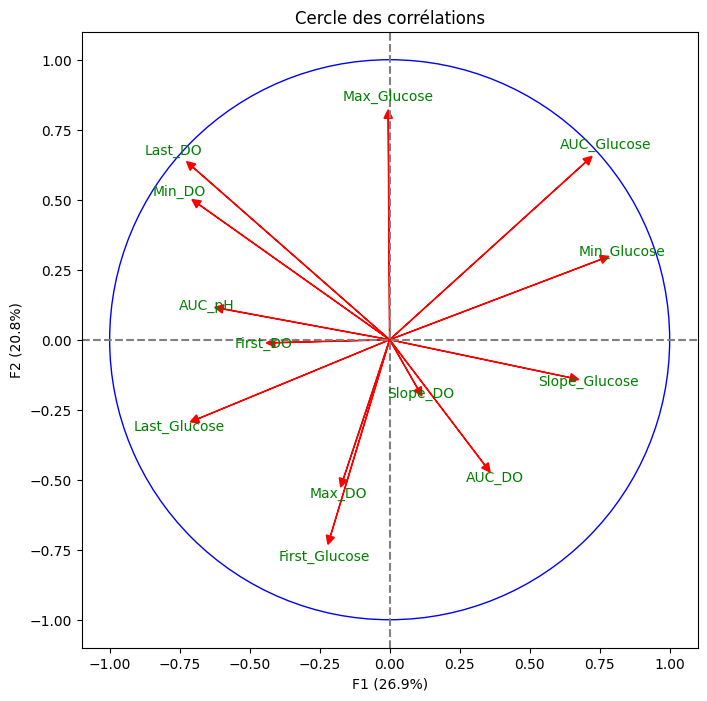

In [179]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

coordonnees_variables = pca.components_.T * np.sqrt(pca.explained_variance_)

# 5. Tracé du cercle des corrélations
fig, ax = plt.subplots(figsize=(8, 8))

# Tracer les axes
ax.axhline(0, color='grey', linestyle='--')
ax.axvline(0, color='grey', linestyle='--')

# Dessiner le cercle unité (rayon = 1)
cercle = plt.Circle((0, 0), 1, color='b', fill=False)
ax.add_artist(cercle)

# Ajouter les vecteurs des variables et leurs noms
for i in range(coordonnees_variables.shape[0]):
    # Tracer la flèche
    ax.arrow(0, 0, coordonnees_variables[i, 0], coordonnees_variables[i, 1], 
             head_width=0.03, head_length=0.03, color='r')
    # Ajouter le texte (nom de la variable)
    ax.text(coordonnees_variables[i, 0] * 1.1, coordonnees_variables[i, 1] * 1.1, 
            dt.columns[i], color='g', ha='center', va='center')

# Configuration des limites et des labels
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel(f'F1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'F2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Cercle des corrélations')
ax.set_aspect('equal') # Pour que le cercle ne soit pas ovale

plt.show()

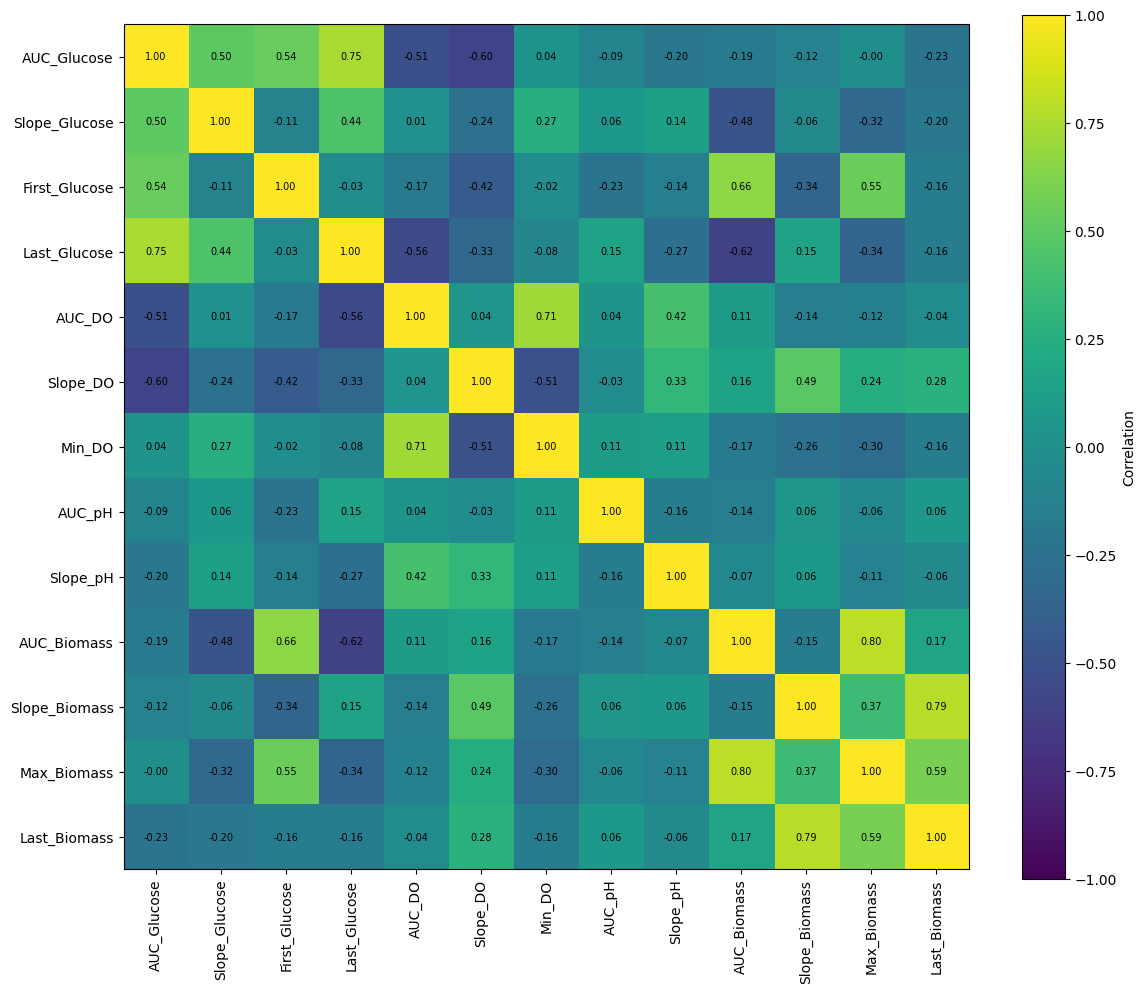

In [180]:
dt_new = dt[selected_features]

corr = dt_new.corr()

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(corr, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)

ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

fig.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

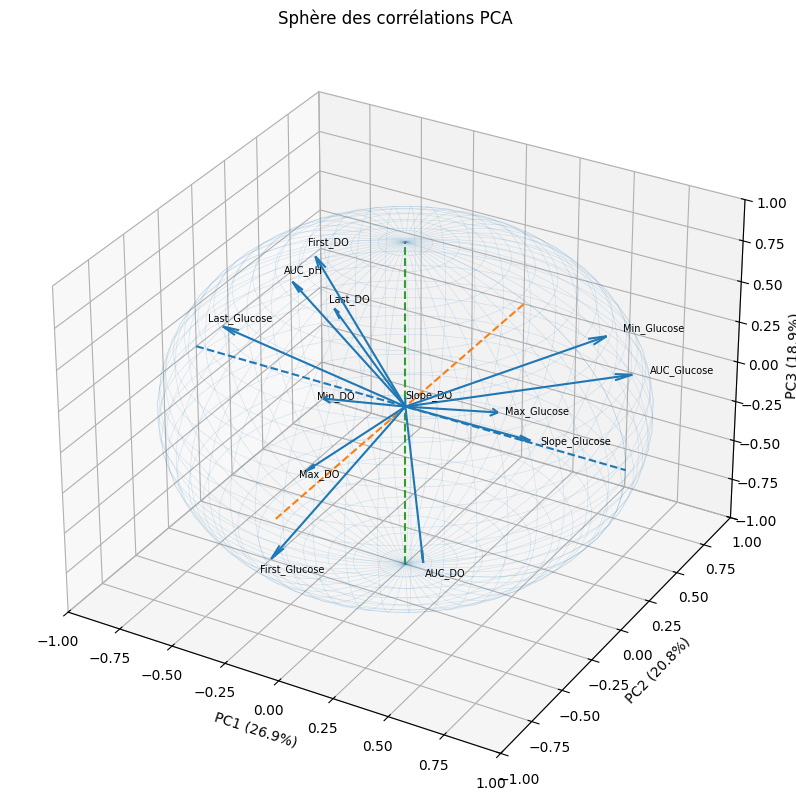

In [181]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

coordonnees_variables = (
    pca.components_.T * np.sqrt(pca.explained_variance_)
)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")

# Sphère unité
u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0, np.pi, 30)

x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones_like(u), np.cos(v))

ax.plot_wireframe(
    x, y, z,
    alpha=0.15,
    linewidth=0.5
)

# Axes
ax.plot([-1, 1], [0, 0], [0, 0], linestyle="--")
ax.plot([0, 0], [-1, 1], [0, 0], linestyle="--")
ax.plot([0, 0], [0, 0], [-1, 1], linestyle="--")

# Variables
for i in range(coordonnees_variables.shape[0]):

    x_var = coordonnees_variables[i, 0]
    y_var = coordonnees_variables[i, 1]
    z_var = coordonnees_variables[i, 2]

    ax.quiver(
        0, 0, 0,
        x_var, y_var, z_var,
        arrow_length_ratio=0.08
    )

    ax.text(
        x_var * 1.08,
        y_var * 1.08,
        z_var * 1.08,
        dt.columns[i],
        fontsize=7
    )

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)
ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)
ax.set_zlabel(
    f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)"
)

ax.set_title("Sphère des corrélations PCA")

plt.show()

In [182]:
from sklearn.preprocessing import StandardScaler

feature_cols = dt.columns

scaler = StandardScaler()
X_scaled = scaler.fit_transform(dt)

dt_scaled = pd.DataFrame(
    X_scaled,
    index=dt.index,
    columns=feature_cols
)

dt_scaled["Cluster"] = clusters

cluster_means = dt_scaled.groupby("Cluster").mean()

In [183]:
cluster_separation = (
    cluster_means.max(axis=0)
    - cluster_means.min(axis=0)
)

cluster_separation = cluster_separation.sort_values(
    ascending=False
)

print(cluster_separation.head(20))

AUC_Biomass      4.155562
Max_Glucose      3.816210
First_Glucose    3.815641
Last_Glucose     3.218820
Min_Glucose      3.213198
Max_Biomass      3.134979
AUC_Glucose      2.979592
Last_DO          2.596709
First_DO         2.481399
Slope_Biomass    2.458822
Last_Biomass     2.424820
Slope_DO         2.184670
Slope_Glucose    1.934650
Min_pH           1.840166
First_pH         1.814565
AUC_pH           1.762154
Last_pH          1.735141
AUC_DO           1.723634
Max_pH           1.716936
Max_DO           1.100340
dtype: float32


In [184]:
top_features = cluster_separation.head(15).index

print(
    cluster_means[top_features].T
)

Cluster               0         1         2         3
AUC_Biomass   -1.773920  0.009365  2.381642  0.027422
Max_Glucose   -0.008833 -0.712487  3.103723 -0.175316
First_Glucose -0.068608 -0.738080  3.077561 -0.157736
Last_Glucose   2.867938 -0.347647 -0.350882 -0.342709
Min_Glucose    2.868927 -0.344271 -0.344271 -0.344271
Max_Biomass   -0.974227  1.058312  2.160751 -0.296425
AUC_Glucose    2.187869 -0.791723  1.386367 -0.324708
Last_DO       -2.308900  0.257480  0.214207  0.287809
First_DO      -2.136726  0.157445  0.344673  0.267950
Slope_Biomass  0.408348  1.954105 -0.504717 -0.422739
Last_Biomass  -0.494251  1.930568 -0.478024 -0.278077
Slope_DO      -1.004732  1.179938 -0.220338 -0.066573
Slope_Glucose  1.455998 -0.292866 -0.478651 -0.117854
Min_pH         0.639942 -0.202884 -1.200224  0.068008
First_pH       0.596810 -0.176850 -1.217755  0.071183


In [185]:
X_cluster = X_pca[:, :5]

distances = np.zeros(len(X_cluster))

for i in range(len(X_cluster)):
    c = clusters[i]
    center = kmeans.cluster_centers_[c]
    
    distances[i] = np.linalg.norm(
        X_cluster[i] - center
    )

outlier_df = pd.DataFrame({
    "Bioreactor": dt.index,
    "Cluster": clusters,
    "Distance_to_cluster": distances
})

print(
    outlier_df.sort_values(
        "Distance_to_cluster",
        ascending=False
    )
)

   Bioreactor  Cluster  Distance_to_cluster
5       B10R2        3             4.408303
10      B24R1        0             3.732741
19      B13R2        1             3.302326
17      B11R2        3             3.246777
15      B17R1        3             3.003564
16      B18R1        1             2.595781
11      B13R1        3             2.474014
27      B21R2        3             2.403634
18      B12R2        3             2.344797
23      B17R2        0             2.262665
26      B20R2        3             2.115604
22      B16R2        0             2.109203
25      B19R2        1             1.950708
20      B14R2        1             1.917865
12      B14R1        3             1.840680
6       B19R1        3             1.772857
2        B7R2        3             1.570757
24      B18R2        3             1.544890
7       B21R1        3             1.514190
8       B22R1        3             1.496892
0        B5R2        3             1.483559
1        B6R2        3          

In [186]:
# Création de la colonne
outlier_df["Outlier"] = False

# Détection des outliers cluster par cluster
for c in np.unique(clusters):

    mask = clusters == c
    d = distances[mask]

    Q1 = np.percentile(d, 25)
    Q3 = np.percentile(d, 75)
    IQR = Q3 - Q1

    threshold = Q3 + 1.5 * IQR

    outlier_df.loc[mask, "Outlier"] = d > threshold

# Afficher les résultats
print(outlier_df)
print("\nOutliers détectés :")
print(outlier_df[outlier_df["Outlier"]])

   Bioreactor  Cluster  Distance_to_cluster  Outlier
0        B5R2        3             1.483559    False
1        B6R2        3             1.421031    False
2        B7R2        3             1.570757    False
3        B8R2        2             0.309110    False
4        B9R2        2             0.309110    False
5       B10R2        3             4.408303     True
6       B19R1        3             1.772857    False
7       B21R1        3             1.514190    False
8       B22R1        3             1.496892    False
9       B23R1        3             1.090845    False
10      B24R1        0             3.732741    False
11      B13R1        3             2.474014    False
12      B14R1        3             1.840680    False
13      B15R1        3             1.246176    False
14      B16R1        3             1.235792    False
15      B17R1        3             3.003564    False
16      B18R1        1             2.595781    False
17      B11R2        3             3.246777   

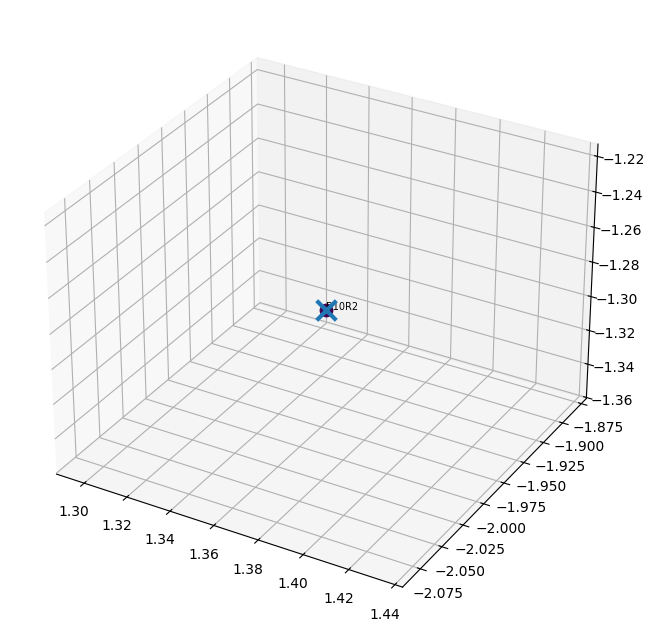

In [187]:
normal = outlier_df["Outlier"].values
outlier = outlier_df["Outlier"].values

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

# Normaux
ax.scatter(
    X_pca[normal, 0],
    X_pca[normal, 1],
    X_pca[normal, 2],
    c=clusters[normal],
    s=80
)

# Outliers
ax.scatter(
    X_pca[outlier, 0],
    X_pca[outlier, 1],
    X_pca[outlier, 2],
    marker="x",
    s=200,
    linewidth=3
)

for i, bio in enumerate(dt.index):
    ax.text(
        X_pca[i,0],
        X_pca[i,1],
        X_pca[i,2],
        str(bio),
        fontsize=7
    )

plt.show()

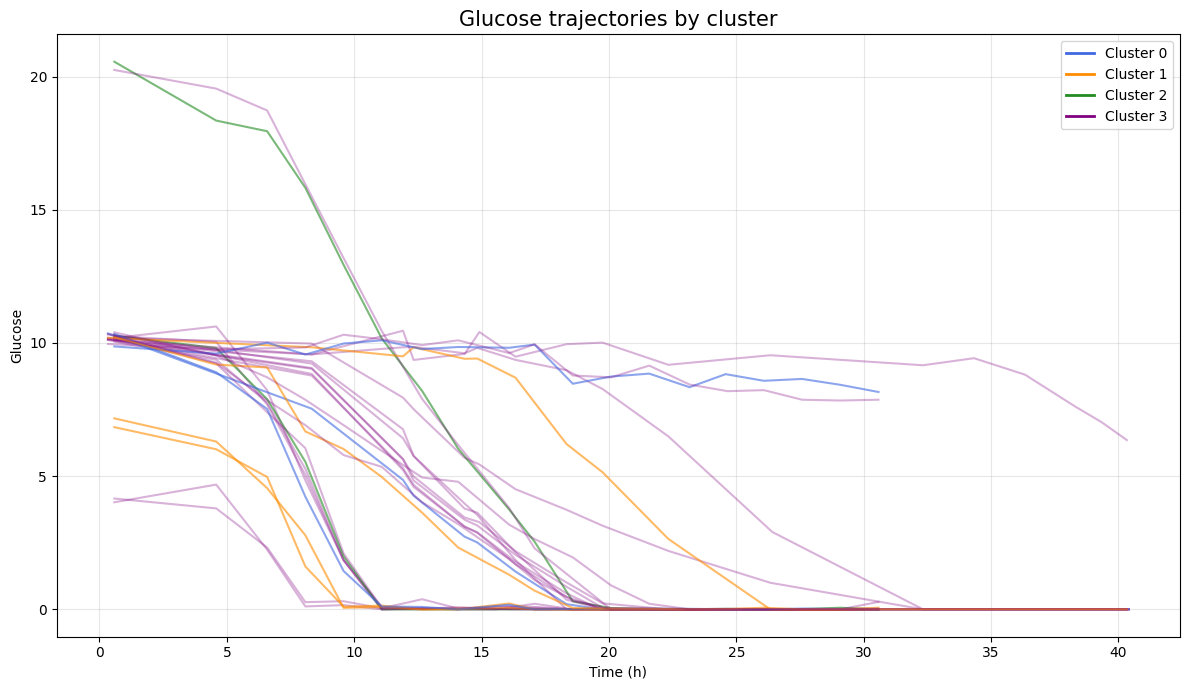

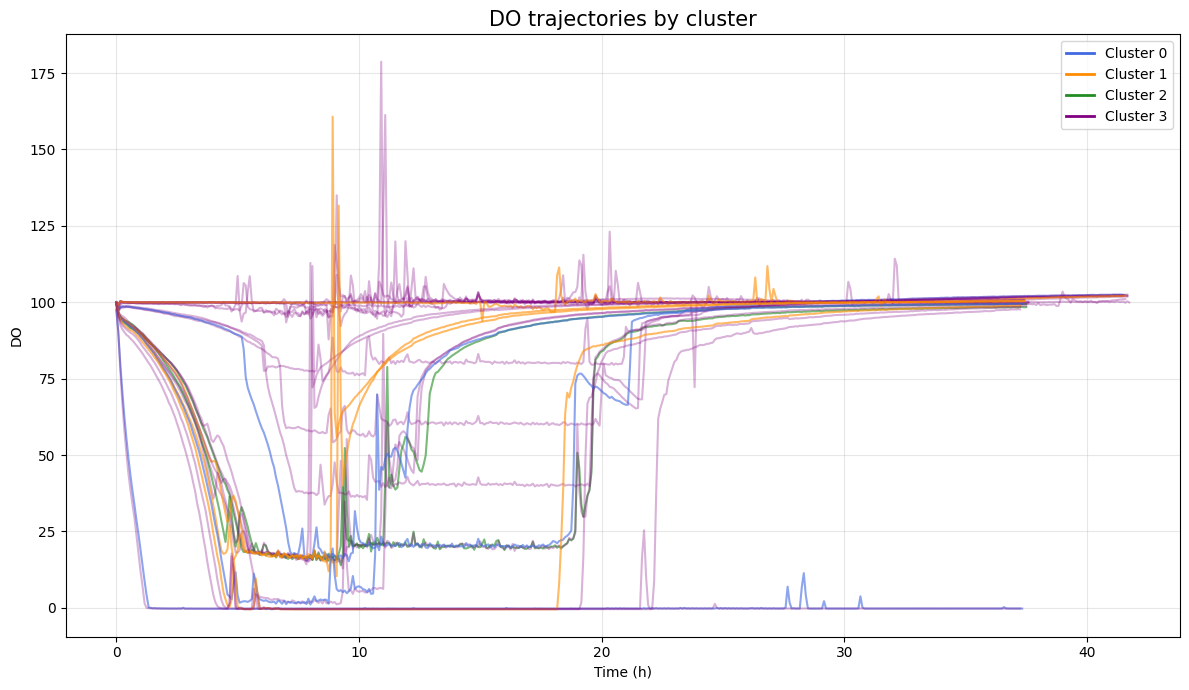

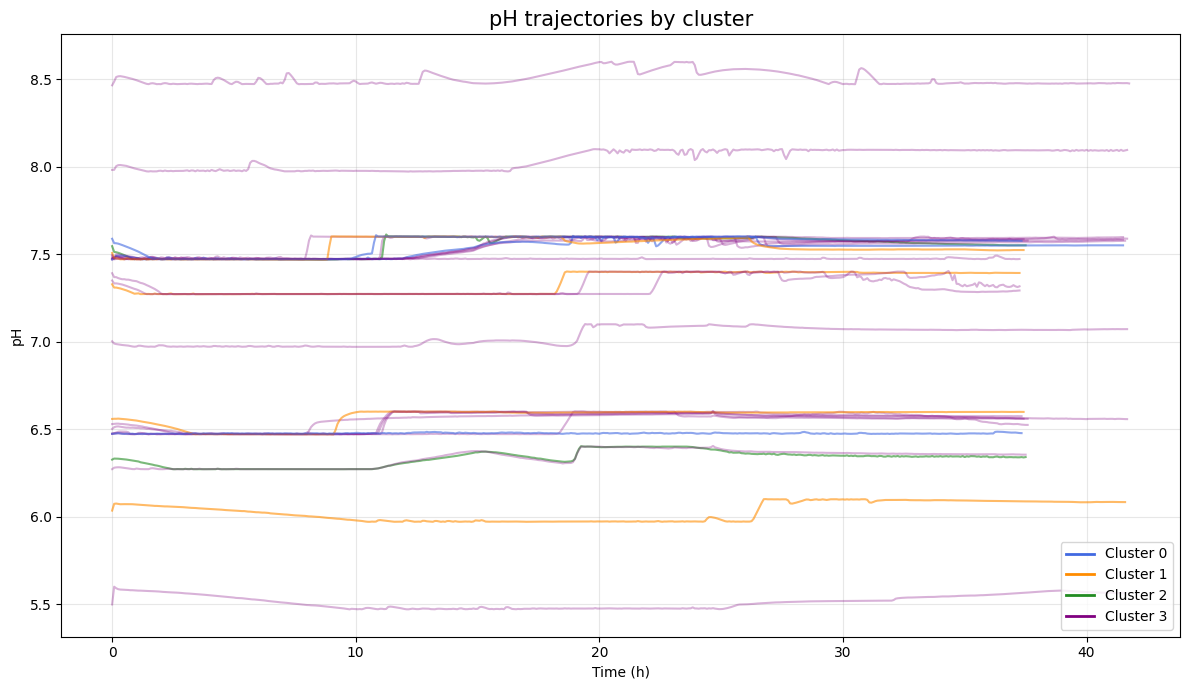

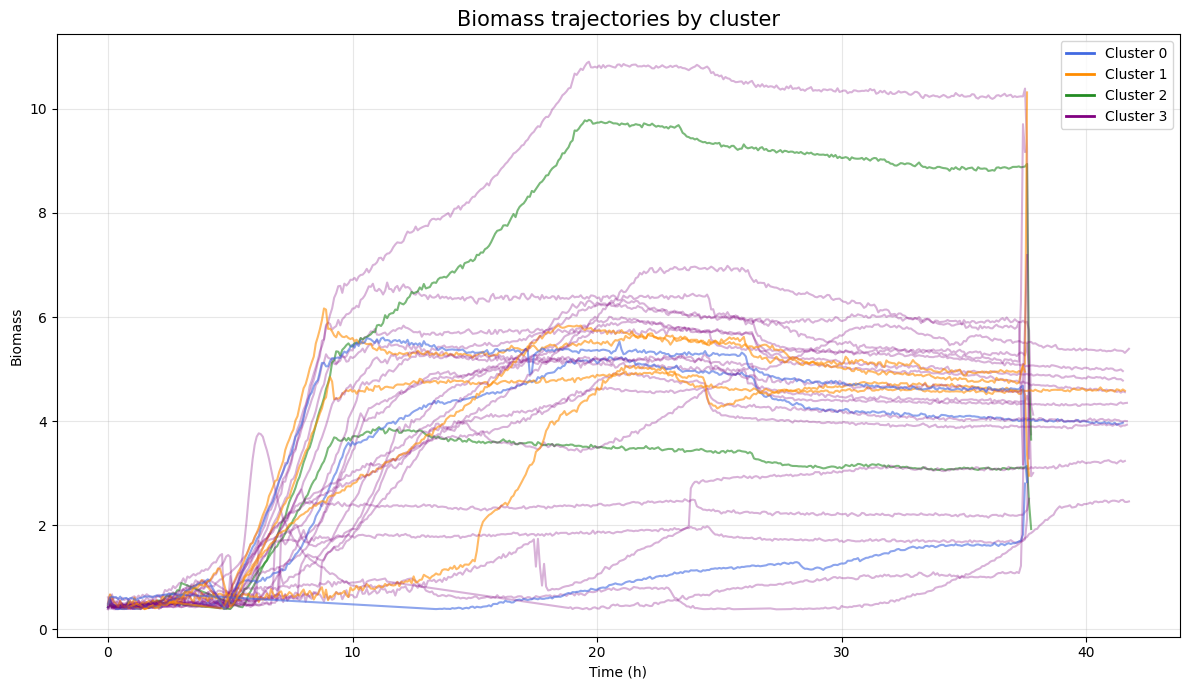

In [195]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

var_names = ["Glucose", "DO", "pH", "Biomass"]

cluster_colors = {
    0: "royalblue",
    1: "darkorange",
    2: "forestgreen",
    3: "purple"
}

for var_idx, var_name in enumerate(var_names):

    fig, ax = plt.subplots(figsize=(12, 7))

    for i, bio in enumerate(dt.index):

        cluster_id = clusters[i]

        if cluster_id == 'B10R2' or cluster_id == 'B13R2' or cluster_id == 'B24R1':
            continue

        time = ts_list[i*4 + var_idx]
        traj = ys_list[i*4 + var_idx]

        if len(time) < 2 or len(traj) < 2:
            continue

        if cluster_colors[cluster_id] == "purple":
            ax.plot(
                time,
                traj,
                color=cluster_colors[cluster_id],
                alpha=0.3,
                linewidth=1.5
            )
        else:
            ax.plot(
                time,
                traj,
                color=cluster_colors[cluster_id],
                alpha=0.6,
                linewidth=1.5
            )

    ax.set_title(f"{var_name} trajectories by cluster", fontsize=15)
    ax.set_xlabel("Time (h)")
    ax.set_ylabel(var_name)
    ax.grid(alpha=0.3)

    # Une légende par cluster, pas une entrée par bioréacteur
    legend_elements = [
        Line2D(
            [0], [0],
            color=cluster_colors[c],
            lw=2,
            label=f"Cluster {c}"
        )
        for c in sorted(np.unique(clusters))
    ]

    ax.legend(handles=legend_elements)

    plt.tight_layout()
    plt.show()

In [196]:
import numpy as np

var_names = ["Glucose", "DO", "pH", "Biomass"]

trajectories = []

# Grille commune, par exemple 100 points
common_time = np.linspace(0, 1, 100)

for i, bio in enumerate(dt.index):

    bio_traj = []

    for var_idx in range(4):

        time = np.asarray(ts_list[i*4 + var_idx])
        traj = np.asarray(ys_list[i*4 + var_idx])

        mask = np.isfinite(time) & np.isfinite(traj)
        time = time[mask]
        traj = traj[mask]

        if len(time) < 2:
            raise ValueError(
                f"Pas assez de points pour {bio} - {var_names[var_idx]}"
            )

        # Temps ramené entre 0 et 1
        time_norm = (time - time.min()) / (time.max() - time.min())

        # Interpolation
        traj_interp = np.interp(
            common_time,
            time_norm,
            traj
        )

        bio_traj.append(traj_interp)

    # shape = (100, 4)
    bio_traj = np.array(bio_traj).T

    trajectories.append(bio_traj)

trajectories = np.array(trajectories)

print(trajectories.shape)

(28, 100, 4)


In [197]:
from sklearn.preprocessing import StandardScaler

n_bio, n_time, n_var = trajectories.shape

scaler_dtw = StandardScaler()

trajectories_scaled = scaler_dtw.fit_transform(
    trajectories.reshape(-1, n_var)
).reshape(n_bio, n_time, n_var)

In [198]:
pip install tslearn

/usr/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 KB 1.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 13.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 12.8 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 9.4 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 KB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 KB 10.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [199]:
from tslearn.metrics import cdist_dtw

dtw_matrix = cdist_dtw(
    trajectories_scaled,
    trajectories_scaled
)

print(dtw_matrix.shape)

(28, 28)


In [201]:
from sklearn.cluster import AgglomerativeClustering

clustering_dtw = AgglomerativeClustering(
    n_clusters=4,
    metric="precomputed",
    linkage="average"
)

clusters_dtw = clustering_dtw.fit_predict(dtw_matrix)

for bio, cluster in zip(dt.index, clusters_dtw):
    print(bio, "-> Cluster", cluster)

B5R2 -> Cluster 0
B6R2 -> Cluster 0
B7R2 -> Cluster 0
B8R2 -> Cluster 0
B9R2 -> Cluster 0
B10R2 -> Cluster 0
B19R1 -> Cluster 3
B21R1 -> Cluster 0
B22R1 -> Cluster 0
B23R1 -> Cluster 0
B24R1 -> Cluster 0
B13R1 -> Cluster 2
B14R1 -> Cluster 0
B15R1 -> Cluster 0
B16R1 -> Cluster 0
B17R1 -> Cluster 0
B18R1 -> Cluster 0
B11R2 -> Cluster 0
B12R2 -> Cluster 0
B13R2 -> Cluster 0
B14R2 -> Cluster 0
B15R2 -> Cluster 0
B16R2 -> Cluster 0
B17R2 -> Cluster 1
B18R2 -> Cluster 1
B19R2 -> Cluster 0
B20R2 -> Cluster 0
B21R2 -> Cluster 0


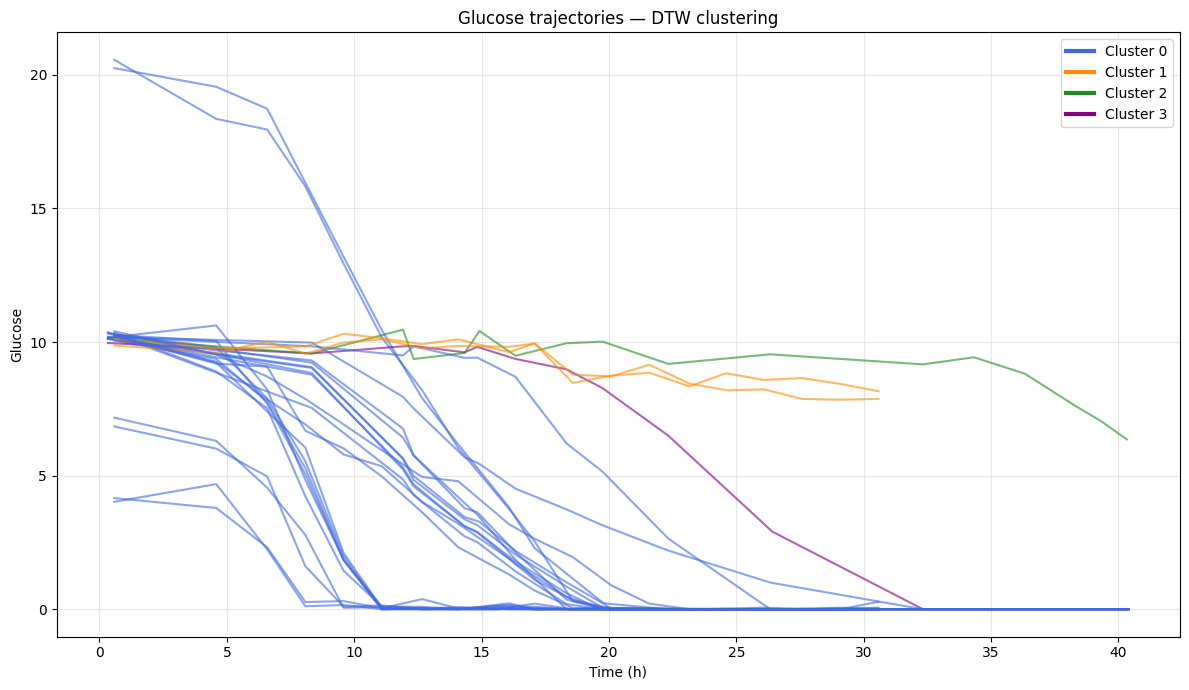

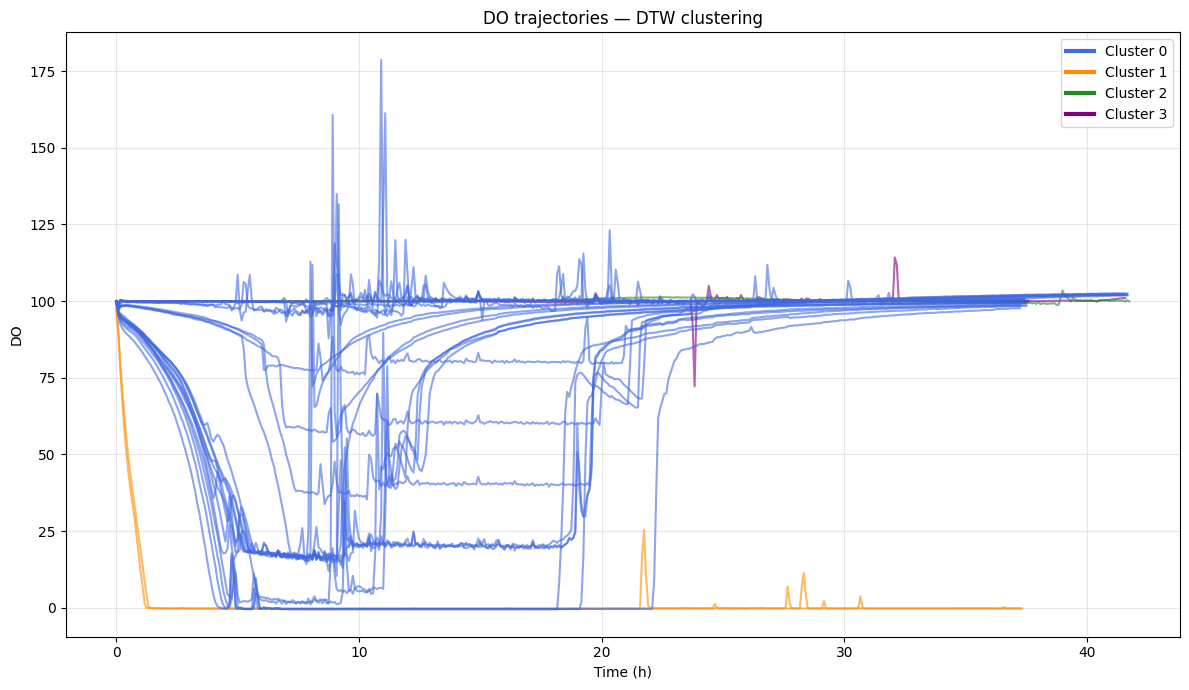

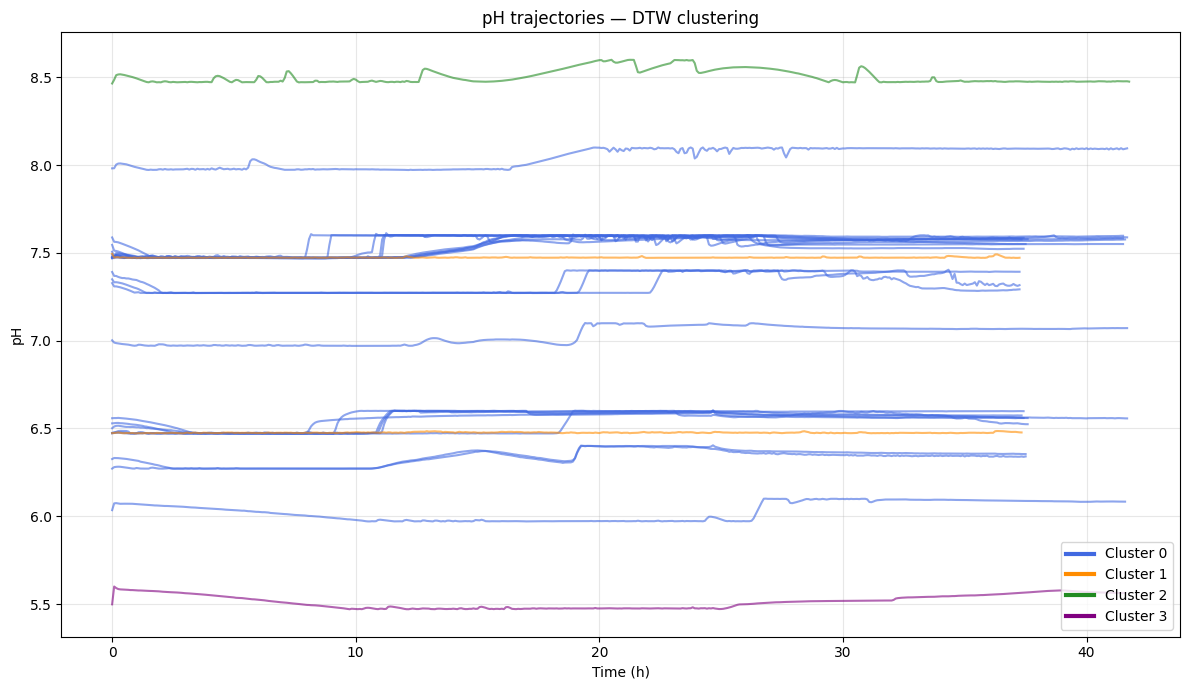

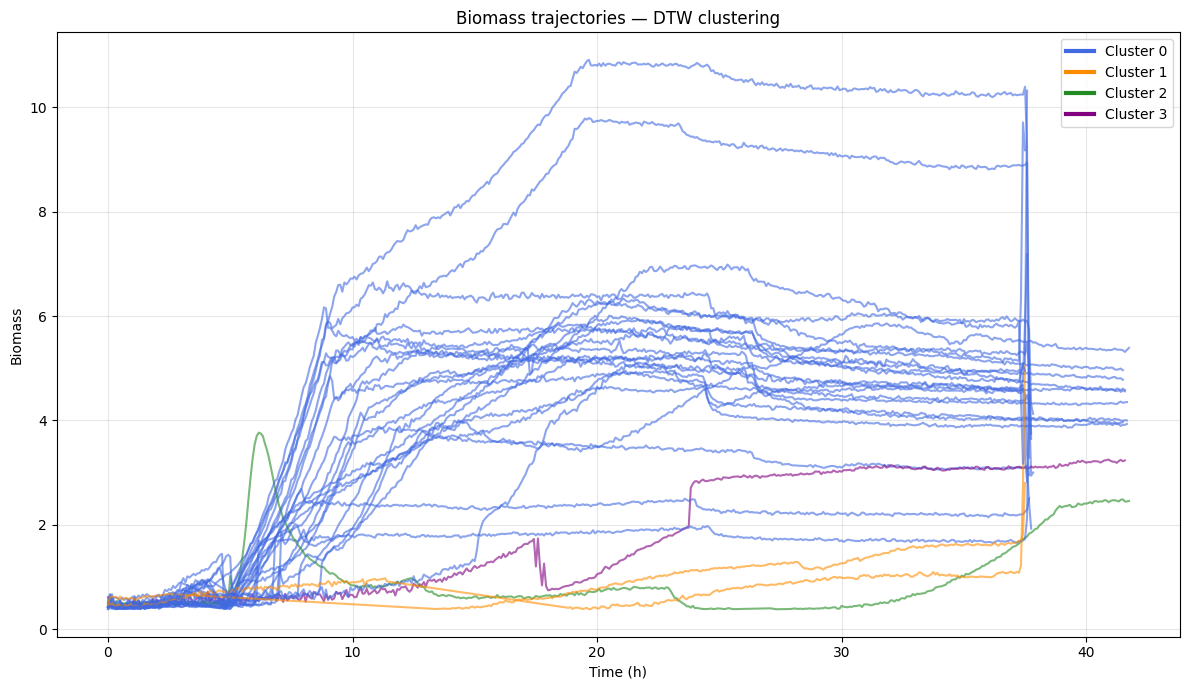

In [202]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

cluster_colors = {
    0: "royalblue",
    1: "darkorange",
    2: "forestgreen",
    3: "purple"
}

for var_idx, var_name in enumerate(var_names):

    fig, ax = plt.subplots(figsize=(12, 7))

    for i, bio in enumerate(dt.index):

        time = ts_list[i*4 + var_idx]
        traj = ys_list[i*4 + var_idx]

        cluster = clusters_dtw[i]

        ax.plot(
            time,
            traj,
            color=cluster_colors[cluster],
            alpha=0.6,
            linewidth=1.5
        )

    legend_elements = [
        Line2D(
            [0], [0],
            color=cluster_colors[c],
            lw=3,
            label=f"Cluster {c}"
        )
        for c in sorted(np.unique(clusters_dtw))
    ]

    ax.legend(handles=legend_elements)

    ax.set_title(
        f"{var_name} trajectories — DTW clustering"
    )

    ax.set_xlabel("Time (h)")
    ax.set_ylabel(var_name)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [203]:
comparison = pd.DataFrame({
    "Cluster_features": clusters,
    "Cluster_DTW": clusters_dtw
}, index=dt.index)

print(comparison)

       Cluster_features  Cluster_DTW
B5R2                  3            0
B6R2                  3            0
B7R2                  3            0
B8R2                  2            0
B9R2                  2            0
B10R2                 3            0
B19R1                 3            3
B21R1                 3            0
B22R1                 3            0
B23R1                 3            0
B24R1                 0            0
B13R1                 3            2
B14R1                 3            0
B15R1                 3            0
B16R1                 3            0
B17R1                 3            0
B18R1                 1            0
B11R2                 3            0
B12R2                 3            0
B13R2                 1            0
B14R2                 1            0
B15R2                 3            0
B16R2                 0            0
B17R2                 0            1
B18R2                 3            1
B19R2                 1            0
B

In [204]:
pd.crosstab(
    comparison["Cluster_features"],
    comparison["Cluster_DTW"]
)

Cluster_DTW,0,1,2,3
Cluster_features,,,,
0,2,1,0,0
1,4,0,0,0
2,2,0,0,0
3,16,1,1,1
